# Chromhandler foundations + plotting — demo

This notebook walks through the **current usable surface** of `chromhandler.fitting`: the foundations layer (data preparation) and the plotting layer (pre-fit diagnostics).

It mirrors the workflow of `test.py` at the repo root, but using the new clean API. The MCMC fitter (`Fitter.fit()`, `plot_traces`, `plot_fit_combined`) is being rewritten on top of these foundations and is not yet available — those calls are deferred to a follow-up plan.

## 1. Load chromatographic data

We use the included ASM kinetic series fixture (7 traces at t = 0, 10, 20, 30, 60, 120, 240 min). For your own data, replace the call with `Handler.read_agilent(...)`, `Handler.read_shimadzu(...)`, etc.

In [1]:
from pathlib import Path

import numpy as np

from chromhandler.handler import Handler

ASM_DIR = Path.cwd().parent / "tests" / "fixtures" / "asm_kinetic_series"

handler = Handler.read_asm(path=ASM_DIR, mode="timecourse")
print(f"loaded {len(handler.samples)} sample(s) with chromatograms across the kinetic series")

loaded 1 sample(s) with chromatograms across the kinetic series


Extract per-trace `(time, signal)` arrays from the handler. Each ASM file in the fixture becomes one chromatogram; we collect them all into matching lists.

In [2]:
times: list[np.ndarray] = []
signals: list[np.ndarray] = []
for sample in handler.samples:
    for chrom in sample.chromatograms:
        times.append(np.asarray(chrom.time, dtype=float))
        signals.append(np.asarray(chrom.signal, dtype=float))

print(f"n_trace = {len(times)}")
print(f"trace lengths: {[t.size for t in times]}")
print(f"time range of trace 0: {times[0][0]:.3f} – {times[0][-1]:.3f} min")

n_trace = 7
trace lengths: [3001, 3001, 3001, 3001, 3001, 3001, 3001]
time range of trace 0: 0.000 – 20.000 min


## 2. Annotate peaks and baseline regions

`PeakAnnotation` defines the retention-time window for one molecule's peak. `BaselineAnnotation` marks signal-free regions used for baseline + noise estimation.

Three peak shape modes:
- `mode="single"` — one component (one skew-normal).
- `mode="artefact_doublet"` + `artefact_side="left"|"right"` — main analyte plus a fixed-side artefact shoulder.
- `mode="free_doublet"` — two independently positioned components (skipped here; the model rewrite will support it).

The `n_components` field is **derived** from `mode` (1 for `"single"`, 2 for either doublet).

In [3]:
from chromhandler.annotations import BaselineAnnotation, PeakAnnotation

peak_annotations = [
    PeakAnnotation(molecule_id="Ino", rt_min=2.55, rt_max=2.85),
    PeakAnnotation(
        molecule_id="SIH",
        rt_min=2.85,
        rt_max=3.15,
        mode="artefact_doublet",
        artefact_side="right",
    ),
    PeakAnnotation(
        molecule_id="Hyp",
        rt_min=3.15,
        rt_max=3.48,
        mode="artefact_doublet",
        artefact_side="left",
        include_artefact_in_area=False,
    ),
]

baseline_annotations = [
    BaselineAnnotation(rt_min=2.49, rt_max=2.51),
    BaselineAnnotation(rt_min=3.50, rt_max=3.52),
]

for ann in peak_annotations:
    print(f"  {ann.molecule_id:5s}  [{ann.rt_min}, {ann.rt_max}]  mode={ann.mode}  n_components={ann.n_components}")

  Ino    [2.55, 2.85]  mode=single  n_components=1
  SIH    [2.85, 3.15]  mode=artefact_doublet  n_components=2
  Hyp    [3.15, 3.48]  mode=artefact_doublet  n_components=2


## 3. Prepare the dataset

`prepare_dataset` runs the full pipeline in one call:
1. Validate that no baseline region overlaps any peak window.
2. Pad variable-length traces to a rectangular `[n_trace, n_time]` array with NaN.
3. Compute per-trace and global `dt`.
4. Fit per-trace OLS baselines through the user-annotated regions (no peak-edge contamination).
5. Estimate per-trace noise via MAD on baseline residuals.
6. Bundle everything into an immutable `PreparedDataset`.

In [4]:
from chromhandler.fitting.prepared_dataset import prepare_dataset

dataset = prepare_dataset(
    times=times,
    signals=signals,
    peak_annotations=peak_annotations,
    baseline_annotations=baseline_annotations,
)

print(f"n_trace            = {dataset.n_trace}")
print(f"signal shape       = {dataset.signal.shape}")
print(f"dt_global          = {dataset.dt_global:.5f} min")
print(f"dt_per_trace       = {np.round(dataset.dt_per_trace, 5)}")
print(f"baseline intercept = {np.round(dataset.baseline_intercept, 3)}")
print(f"baseline slope     = {np.round(dataset.baseline_slope, 4)}")
print(f"noise per trace    = {np.round(dataset.noise_per_trace, 4)}")

n_trace            = 7
signal shape       = (7, 3001)
dt_global          = 0.00667 min
dt_per_trace       = [0.00667 0.00667 0.00667 0.00667 0.00667 0.00667 0.00667]
baseline intercept = [1992.592 2889.569 2102.726 3643.697 3867.797 2781.875 2597.845]
baseline slope     = [-437.73   -683.651  -429.3959 -912.8642 -973.3807 -596.9676 -528.4282]
noise per trace    = [15.6886  9.7224  5.2909 11.2202 17.525  48.2145 28.8768]


## 4. Quick overview plot

`plot_overview` shows each trace with annotation regions shaded — a sanity check that the data + annotation windows look right before going further.

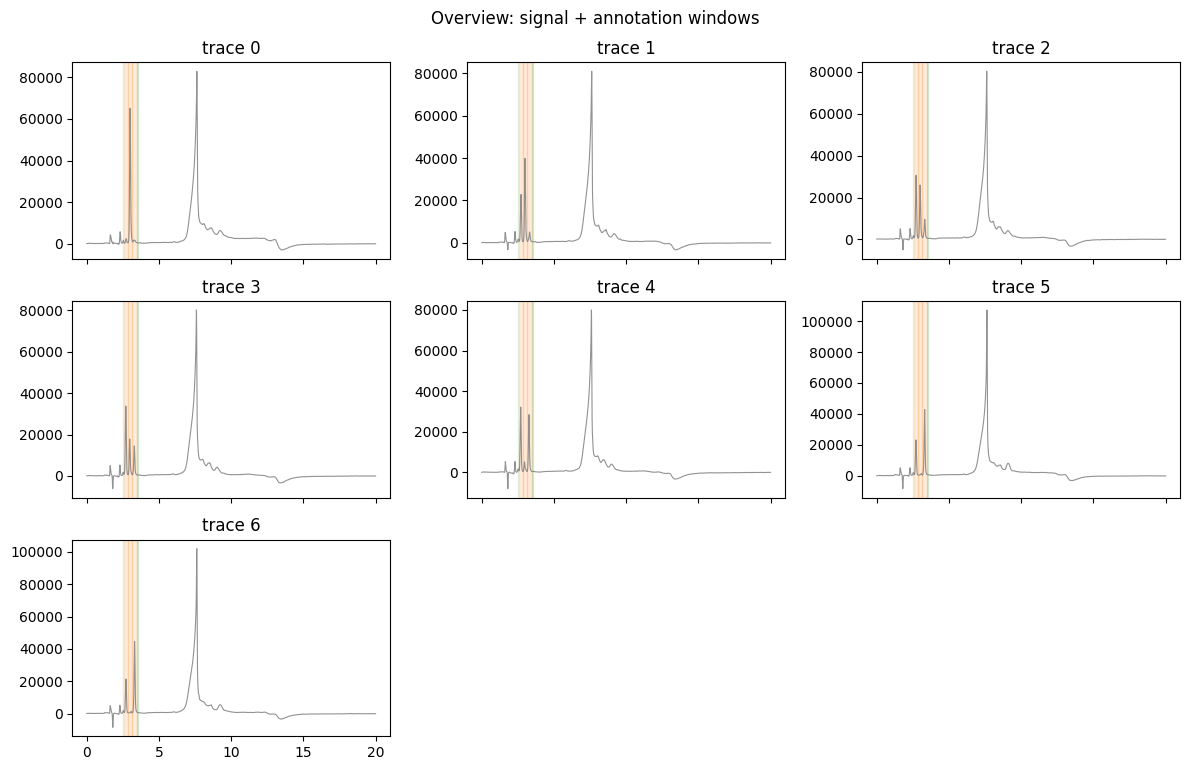

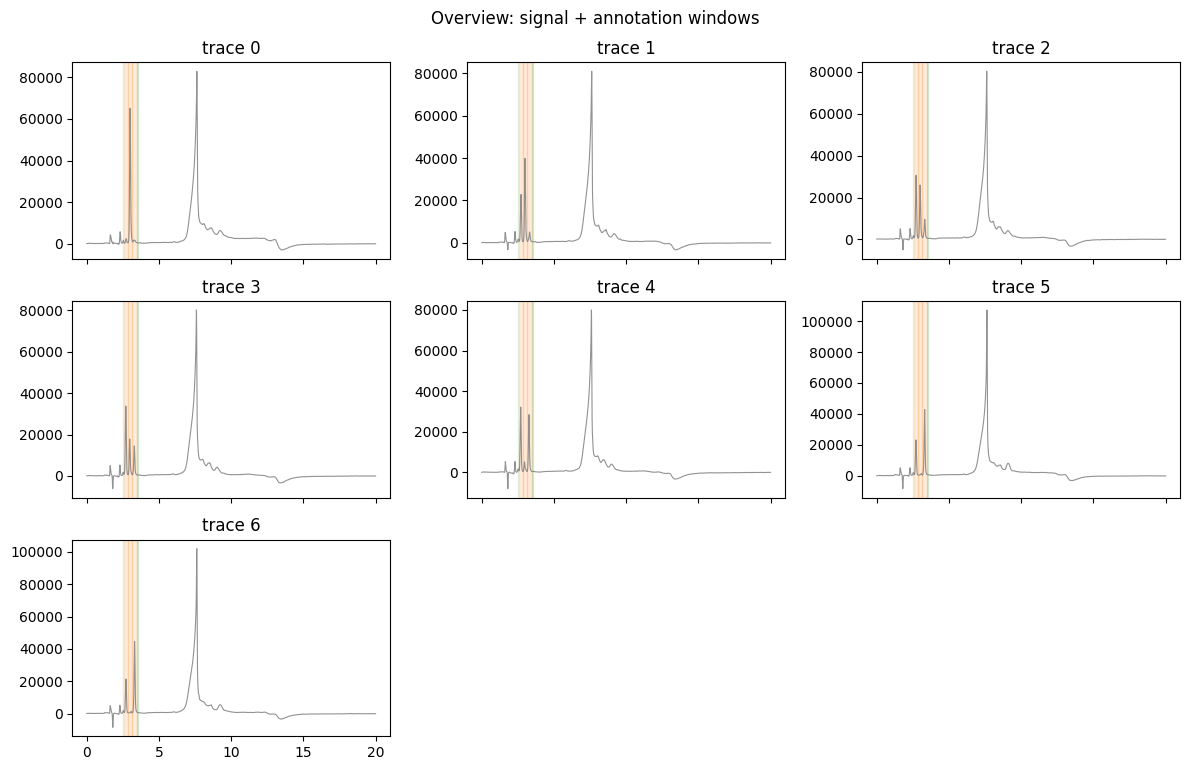

In [5]:
from chromhandler.fitting.plotting import plot_overview

fig = plot_overview(dataset, n_cols=3)
fig.suptitle("Overview: signal + annotation windows", y=1.02)
fig

## 5. Baseline diagnostic — the canonical pre-fit check

`plot_baseline_diagnostic` is the diagnostic to look at before committing to MCMC. Each panel shows:
- Raw signal (gray line).
- Annotation regions (orange = peak, green = baseline).
- The OLS baseline as a dashed blue line across the full time range.
- A translucent ±noise ribbon around the baseline.
- The per-trace `dt` and noise σ in the panel title.

What you want to see:
- The dashed line passes cleanly through the green baseline regions.
- The ribbon width matches what you'd eyeball as "noise" off-peak.
- Outside the peak windows, the signal sits inside the ribbon.

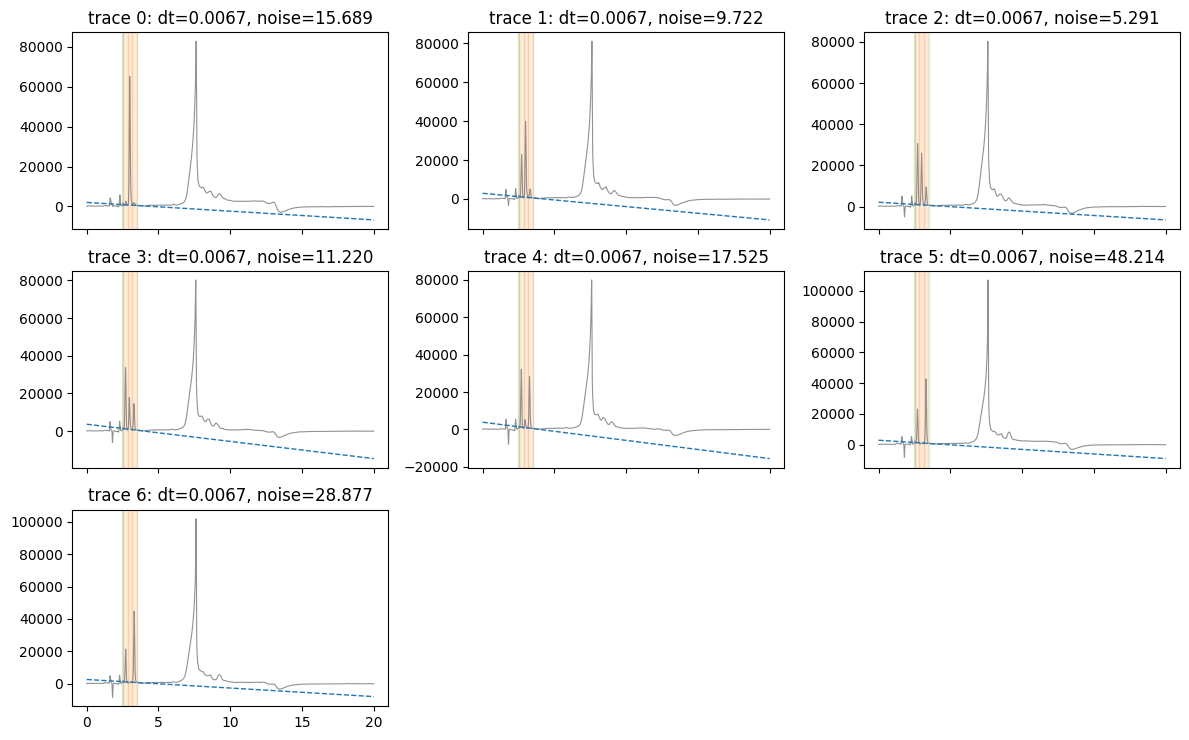

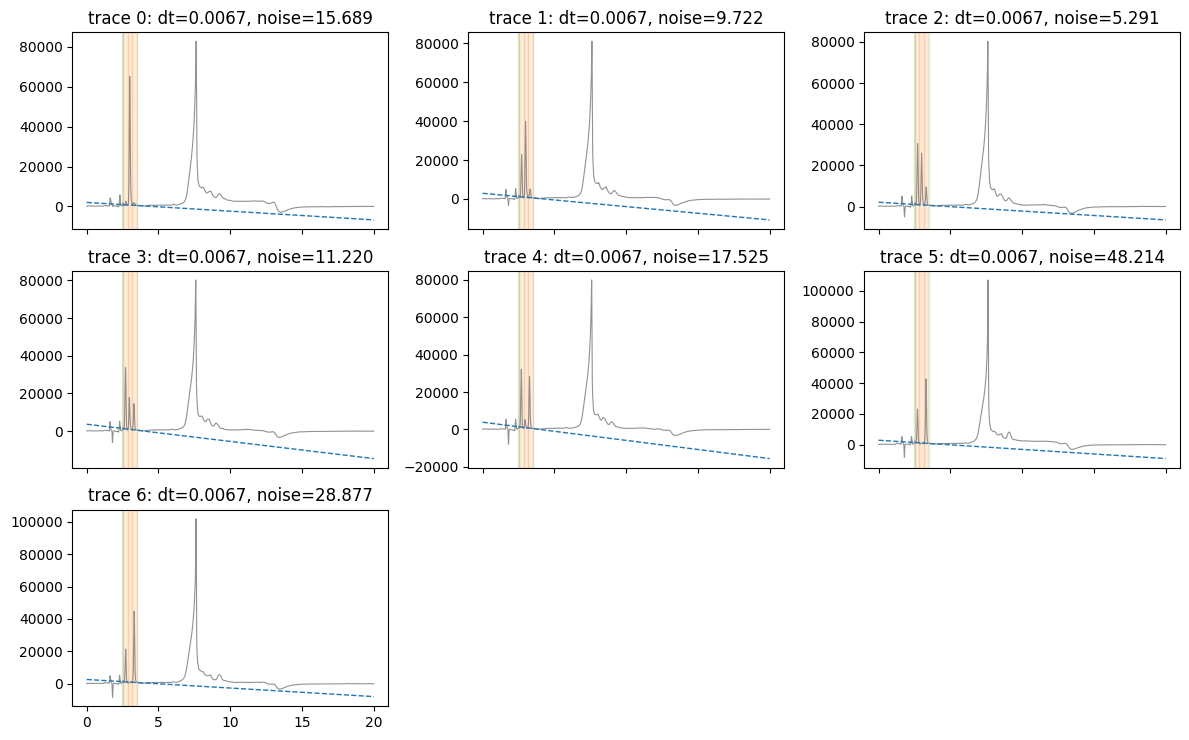

In [6]:
from chromhandler.fitting.plotting import plot_baseline_diagnostic

fig = plot_baseline_diagnostic(dataset, n_cols=3)
fig

## 6. Custom layouts via the axes primitives

Both `plot_overview` and `plot_baseline_diagnostic` are convenience wrappers around four free axes-level primitives:

- `add_signal(ax, dataset, trace_idx)`
- `add_baseline(ax, dataset, trace_idx, show_noise_band=True)`
- `add_annotation_regions(ax, dataset)`
- `add_model(ax, dataset, trace_idx, model_fn=callable)`

Each takes an existing `Axes` and mutates it. Compose them however you like.

Below: zoom in on a single trace with a hand-crafted Gaussian model overlay (just to demonstrate `add_model`'s callable-injection API). Useful for prior predictive checks once the model layer lands.

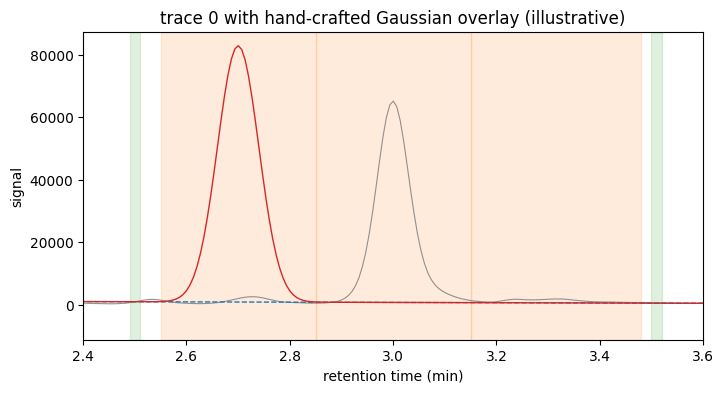

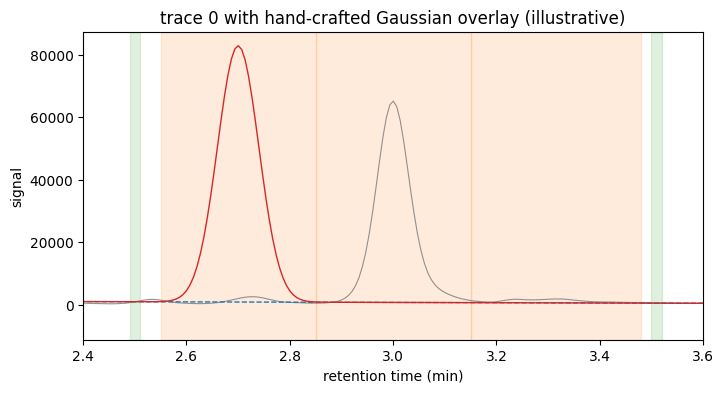

In [7]:
import matplotlib.pyplot as plt

from chromhandler.fitting.plotting import (
    add_annotation_regions,
    add_baseline,
    add_model,
    add_signal,
)


def gaussian_at(mu: float, sigma: float, height: float):
    """Closure: a model_fn that ignores trace_idx and returns a fixed Gaussian."""

    def model_fn(t: np.ndarray, _trace_idx: int) -> np.ndarray:
        return height * np.exp(-0.5 * ((t - mu) / sigma) ** 2)

    return model_fn


trace_idx = 0
fig, ax = plt.subplots(figsize=(8, 4))
add_annotation_regions(ax, dataset)
add_signal(ax, dataset, trace_idx=trace_idx)
add_baseline(ax, dataset, trace_idx=trace_idx, show_noise_band=True)

# Overlay a hand-picked Gaussian centered on the inosine window for illustration.
intercept = dataset.baseline_intercept[trace_idx]
slope = dataset.baseline_slope[trace_idx]
ino_apex_t = 2.70
ino_height = float(
    np.nanmax(dataset.signal[trace_idx]) - (intercept + slope * ino_apex_t)
)
add_model(
    ax,
    dataset,
    trace_idx=trace_idx,
    model_fn=lambda t, i: (intercept + slope * t)
    + gaussian_at(mu=2.70, sigma=0.04, height=ino_height)(t, i),
)
ax.set_xlim(2.4, 3.6)
ax.set_xlabel("retention time (min)")
ax.set_ylabel("signal")
ax.set_title("trace 0 with hand-crafted Gaussian overlay (illustrative)")
fig

## 7. What's next

Once the Fitter / skew-normal model rewrite lands on top of these foundations, the workflow becomes:

```python
from chromhandler.fitting.fitter import Fitter

fitter = Fitter(dataset)
fitter.fit(num_warmup=500, num_samples=500, num_chains=8, seed=42)

fitter.save_summary("posterior_summary.txt")
fitter.plot_fit(path="fit.png")  # uses add_posterior_band on the same axes pattern
fitter.plot_traces(path="traces.png")
```

The plotting primitives shown above (`add_*`) extend cleanly with a `add_posterior_band(ax, dataset, samples, ...)` helper, so user code that builds custom layouts won't need changes when the Fitter ships.